In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import os
os.getcwd()
%matplotlib inline

In [40]:
df = pd.read_csv('..\data\processed\cleaned_grades.csv')
df.head()

,Year,Term,YearTerm,Subject,Number,Course Title,Sched Type,A+,A,A-,...,D+,D,D-,F,W,Students,Primary Instructor,Course,Average_GPA,Instructor_Avg_GPA
0,2025,Spring,2025-sp,AAS,100,Intro Asian American Studies,LCD,3,21,1,...,0,0,0,1,0,28,"Geng, Zhe",AAS 100,3.75,3.75
1,2025,Spring,2025-sp,AAS,200,U.S. Race and Empire,LCD,0,33,0,...,0,0,0,1,0,34,"Sawada, Emilia R",AAS 200,3.88,3.89
2,2025,Spring,2025-sp,AAS,211,Asian Americans and the Arts,LCD,0,22,1,...,0,0,0,0,0,24,"Sawada, Emilia R",AAS 211,3.96,3.89
3,2025,Spring,2025-sp,AAS,215,US Citizenship Comparatively,LCD,5,12,5,...,0,1,0,0,0,30,"Siglos, David G",AAS 215,3.66,3.57
4,2025,Spring,2025-sp,AAS,287,Food and Asian Americans,LCD,9,12,8,...,0,0,0,0,1,31,"Kang, Simrat A",AAS 287,3.82,3.82


In [41]:
columns_to_drop = ["Average_GPA", "Year", "Term", "YearTerm", "Subject", "Number", "Course Title", "Sched Type", "A+", "A", "A-", "B+", "B", "B-", "C+", "C", "C-", "D+", "D", "D-", "F", "W", "Primary Instructor", "Course"]
X = df.drop(columns=columns_to_drop)
y = df["Average_GPA"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=11, test_size=0.2)

In [42]:
model = LinearRegression()

In [43]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
predict = model.predict(X_test)

In [45]:
mae = mean_absolute_error(y_test, predict)
mse = mean_squared_error(y_test, predict)
r2 = r2_score(y_test, predict)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R²: {r2}")

MAE: 0.1747270897375265
MSE: 0.0589630814188049
R²: 0.6177423690997124


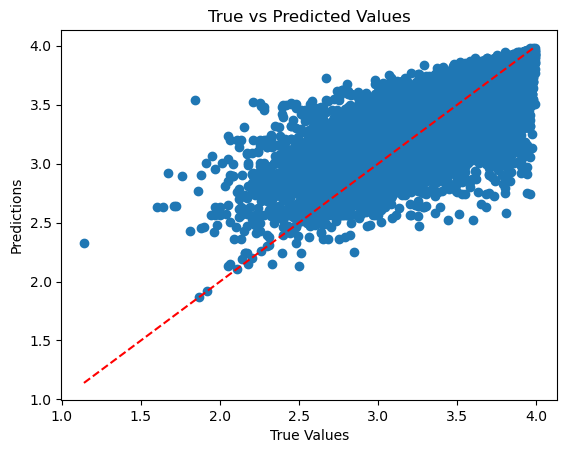

In [46]:
plt.scatter(y_test, predict)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.title("True vs Predicted Values")
plt.show()